# Training Data (70%) - Cafe Location Suitability Model
This notebook loads and displays the **training dataset** containing 70% of all cafe records from **kathmandu_cafes.csv** (2,754 total samples) used for model training.

In [34]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# Set data directory
DATA_DIR = '../data/raw_data'

print("Loading all 8 datasets...")
amenities_df = pd.read_csv(os.path.join(DATA_DIR, 'amenities_clean.csv'))
features_df = pd.read_csv(os.path.join(DATA_DIR, 'dataset_ft_enriched.csv'))
cafes_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_cafes.csv'))  # PRIMARY
census_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_census.csv'))
education_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_education_cleaned.csv'))
osm_amenities_df = pd.read_csv(os.path.join(DATA_DIR, 'osm_amenities_kathmandu.csv'))
roads_df = pd.read_csv(os.path.join(DATA_DIR, 'osm_roads_kathmandu.csv'))
wards_df = pd.read_csv(os.path.join(DATA_DIR, 'kathmandu_wards_boundary_sorted.csv'))

print(f"✓ All datasets loaded successfully")
print(f"Primary dataset: {len(cafes_df):,} cafes")

Loading all 8 datasets...
✓ All datasets loaded successfully
Primary dataset: 2,754 cafes


In [42]:
# Load pre-computed features and target from the main training notebook
# These should have been saved as pickle files
import pickle

# Load features (X) and target (y)
try:
    with open('../data/X_features.pkl', 'rb') as f:
        X = pickle.load(f)
    with open('../data/y_target.pkl', 'rb') as f:
        y = pickle.load(f)
    print(f"✓ Loaded pre-computed features and target")
except FileNotFoundError:
    print("Features/target files not found. Performing full dataset integration...")
    
    # ============================================================================
    # STEP 1: SPATIAL MERGING - Combine all 8 datasets like original project
    # ============================================================================
    
    # Import required functions from original notebooks
    import math
    
    def haversine_distance(lat1, lon1, lat2, lon2):
        """Calculate haversine distance between two points in kilometers"""
        R = 6371  # Earth's radius in kilometers
        
        # Convert to radians
        lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
        lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
        
        # Differences
        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad
        
        # Haversine formula
        a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
        
        return R * c
    
    def count_nearby(lat, lng, df, radius_km=0.5):
        """Count points within radius of a location"""
        if df is None or df.empty:
            return 0
        
        count = 0
        for _, row in df.iterrows():
            if pd.notna(row.get('lat')) and pd.notna(row.get('lng')):
                dist = haversine_distance(lat, lng, row['lat'], row['lng'])
                if dist <= radius_km:
                    count += 1
        return count
    
    # Start with primary cafes dataset
    merged_df = cafes_df.copy()
    print(f"✓ Starting with primary dataset: {len(merged_df)} cafes")
    
    # 1. Merge with enriched features (200m proximity)
    print("  → Merging enriched features (200m radius)...")
    merged_df['population_density'] = 0.0
    merged_df['accessibility_score'] = 0.0
    merged_df['foot_traffic_score'] = 0.0
    
    for idx, cafe in merged_df.iterrows():
        # Find closest enriched feature within 200m
        min_dist = float('inf')
        best_match = None
        
        for _, feature in features_df.iterrows():
            dist = haversine_distance(cafe['lat'], cafe['lng'], feature['lat'], feature['lng'])
            if dist < min_dist and dist <= 0.2:  # 200m
                min_dist = dist
                best_match = feature
        
        if best_match is not None:
            merged_df.at[idx, 'population_density'] = best_match.get('population_density', 0)
            merged_df.at[idx, 'accessibility_score'] = best_match.get('accessibility_score', 0)
            merged_df.at[idx, 'foot_traffic_score'] = best_match.get('foot_traffic_score', 0)
    
    # 2. Add census data (ward-based)
    print("  → Adding census demographics...")
    merged_df['ward_population'] = 0
    
    for idx, cafe in merged_df.iterrows():
        # Find ward containing this cafe
        for _, ward in wards_df.iterrows():
            # Simple ward assignment (could be improved with proper GIS)
            if abs(cafe['lat'] - ward.get('lat', 0)) < 0.01 and abs(cafe['lng'] - ward.get('lng', 0)) < 0.01:
                ward_name = ward.get('ward')
                census_match = census_df[census_df['ward'] == ward_name]
                if not census_match.empty:
                    merged_df.at[idx, 'ward_population'] = census_match.iloc[0].get('population', 0)
                break
    
    # 3. Count nearby amenities (500m radius)
    print("  → Counting nearby amenities (500m radius)...")
    merged_df['schools_within_500m'] = 0
    merged_df['hospitals_within_500m'] = 0
    merged_df['bus_stops_within_500m'] = 0
    
    for idx, cafe in merged_df.iterrows():
        merged_df.at[idx, 'schools_within_500m'] = count_nearby(cafe['lat'], cafe['lng'], education_df, 0.5)
        merged_df.at[idx, 'hospitals_within_500m'] = count_nearby(cafe['lat'], cafe['lng'], amenities_df[amenities_df['type'] == 'hospital'], 0.5)
        merged_df.at[idx, 'bus_stops_within_500m'] = count_nearby(cafe['lat'], cafe['lng'], osm_amenities_df[osm_amenities_df['amenity'] == 'bus_station'], 0.5)
    
    # 4. Competition analysis
    print("  → Analyzing competition...")
    merged_df['competitors_within_200m'] = 0
    merged_df['competitors_within_500m'] = 0
    
    for idx, cafe in merged_df.iterrows():
        # Count other cafes within radii
        competitors_200m = 0
        competitors_500m = 0
        
        for _, other_cafe in merged_df.iterrows():
            if idx != other_cafe.name:  # Don't count self
                dist = haversine_distance(cafe['lat'], cafe['lng'], other_cafe['lat'], other_cafe['lng'])
                if dist <= 0.2:
                    competitors_200m += 1
                if dist <= 0.5:
                    competitors_500m += 1
        
        merged_df.at[idx, 'competitors_within_200m'] = competitors_200m
        merged_df.at[idx, 'competitors_within_500m'] = competitors_500m
    
    # Calculate competition pressure (inverse of competitor count)
    merged_df['competition_pressure'] = 1.0 / (merged_df['competitors_within_500m'] + 1)
    
    print(f"✓ Spatial merging complete: {len(merged_df)} cafes with {len(merged_df.columns)} features")
    
    # ============================================================================
    # STEP 2: FEATURE ENGINEERING - Create final feature matrix
    # ============================================================================
    
    # Select features for model (same as original notebooks)
    feature_columns = [
        'population_density', 'accessibility_score', 'foot_traffic_score',
        'competition_pressure', 'competitors_within_200m', 'bus_stops_within_500m',
        'schools_within_500m', 'hospitals_within_500m', 'ward_population'
    ]
    
    # Add customer experience features
    merged_df['rating_normalized'] = merged_df['rating'] / 5.0  # Normalize to 0-1
    merged_df['review_normalized'] = merged_df['review_count'] / merged_df['review_count'].max()  # Normalize to 0-1
    
    feature_columns.extend(['rating_normalized', 'review_normalized'])
    
    # Create feature matrix
    X = merged_df[feature_columns].fillna(0)
    
    # Normalize all features to 0-1 scale
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    
    # ============================================================================
    # STEP 3: TARGET CREATION - AHP-based suitability score
    # ============================================================================
    
    # AHP weights (from original project)
    ahp_weights = np.array([0.286, 0.204, 0.148, 0.048, 0.081, 0.088, 0.089, 0.057])
    
    # Create AHP suitability score
    y = (
        ahp_weights[0] * X_scaled['population_density'] +
        ahp_weights[1] * X_scaled['accessibility_score'] +
        ahp_weights[2] * X_scaled['foot_traffic_score'] +
        ahp_weights[3] * X_scaled['competition_pressure'] +
        ahp_weights[4] * X_scaled['competitors_within_200m'] +
        ahp_weights[5] * X_scaled['bus_stops_within_500m'] +
        ahp_weights[6] * X_scaled['rating_normalized'] +
        ahp_weights[7] * X_scaled['review_normalized']
    )
    
    X = X_scaled
    print(f"✓ Created feature matrix: {X.shape} with AHP-weighted target: {y.shape}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape if hasattr(y, 'shape') else 'None (no target found)'}")

Features/target files not found. Performing full dataset integration...
✓ Starting with primary dataset: 2754 cafes
  → Merging enriched features (200m radius)...
  → Adding census demographics...
  → Counting nearby amenities (500m radius)...


KeyError: 'amenity'

In [36]:
# Perform 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,  # 30% for testing
    random_state=42
)

print("="*80)
print("TRAIN-TEST SPLIT SUMMARY (70/30 Strategy)")
print("="*80)
print(f"\nTotal samples:     {len(X):,}")
print(f"Training samples:  {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test samples:      {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nFeatures per sample: {X_train.shape[1]}")
print(f"Random seed: 42 (for reproducibility)")
print(f"\n✓ Training data shape: {X_train.shape}")
print(f"✓ Training target shape: {y_train.shape}")

TRAIN-TEST SPLIT SUMMARY (70/30 Strategy)

Total samples:     2,754
Training samples:  1,927 (70.0%)
Test samples:      827 (30.0%)

Features per sample: 5
Random seed: 42 (for reproducibility)

✓ Training data shape: (1927, 5)
✓ Training target shape: (1927,)


## TRAINING DATA (70% - {len(X_train):,} samples from 2,754 total cafes)

In [37]:
# Display first 10 training samples
print("\n" + "="*80)
print("FIRST 10 TRAINING SAMPLES - FEATURES (X_train)")
print("="*80)
display(X_train.head(10))

print("\nFirst 10 training target values (y_train):")
print(y_train.head(10).values)


FIRST 10 TRAINING SAMPLES - FEATURES (X_train)


,rating,review_count,price_level,lat,lng
2179,0.800,0.001685,0.333333,0.460203,0.288434
351,0.700,0.007415,0.000000,0.991669,0.590346
668,0.775,0.004550,0.333333,0.649289,0.569289
1010,0.850,0.012471,0.333333,0.377228,0.768477
128,0.800,0.082744,0.333333,0.667143,0.390667
340,0.850,0.002191,0.333333,0.861384,0.548594
7,0.775,0.038086,0.333333,0.647404,0.512443
1014,0.750,0.010785,0.333333,0.381761,0.780117
1551,0.825,0.003876,0.333333,0.131685,0.759242
1234,0.825,0.005056,0.333333,0.187131,0.594976



First 10 training target values (y_train):
[0.49127078 0.56132522 0.50562724 0.53435973 0.53104685 0.54448949
 0.51275134 0.49466285 0.50904244 0.50395538]


In [38]:
# Training data statistics
print("\n" + "="*80)
print("TRAINING DATA STATISTICS")
print("="*80)

print("\nTarget Variable (y_train) Statistics:")
print(f"  Count:     {y_train.count()}")
print(f"  Mean:      {y_train.mean():.4f}")
print(f"  Std Dev:   {y_train.std():.4f}")
print(f"  Min:       {y_train.min():.4f}")
print(f"  25%:       {y_train.quantile(0.25):.4f}")
print(f"  Median:    {y_train.median():.4f}")
print(f"  75%:       {y_train.quantile(0.75):.4f}")
print(f"  Max:       {y_train.max():.4f}")

print("\nFeature Matrix (X_train) Statistics:")
feature_stats = X_train.describe().T
display(feature_stats)


TRAINING DATA STATISTICS

Target Variable (y_train) Statistics:
  Count:     1927
  Mean:      0.5298
  Std Dev:   0.0460
  Min:       0.1888
  25%:       0.4958
  Median:    0.5224
  75%:       0.5631
  Max:       0.7763

Feature Matrix (X_train) Statistics:


,count,mean,std,min,25%,50%,75%,max
rating,1927.0,0.815698,0.058910,0.000000,0.775000,0.825000,0.850000,1.000000
review_count,1927.0,0.018880,0.052359,0.000000,0.002359,0.005056,0.012302,0.724469
price_level,1927.0,0.259644,0.169468,0.000000,0.000000,0.333333,0.333333,1.000000
lat,1927.0,0.517257,0.198187,0.000000,0.386737,0.504560,0.654834,0.997228
lng,1927.0,0.479056,0.207432,0.009054,0.297488,0.515185,0.600241,1.000000


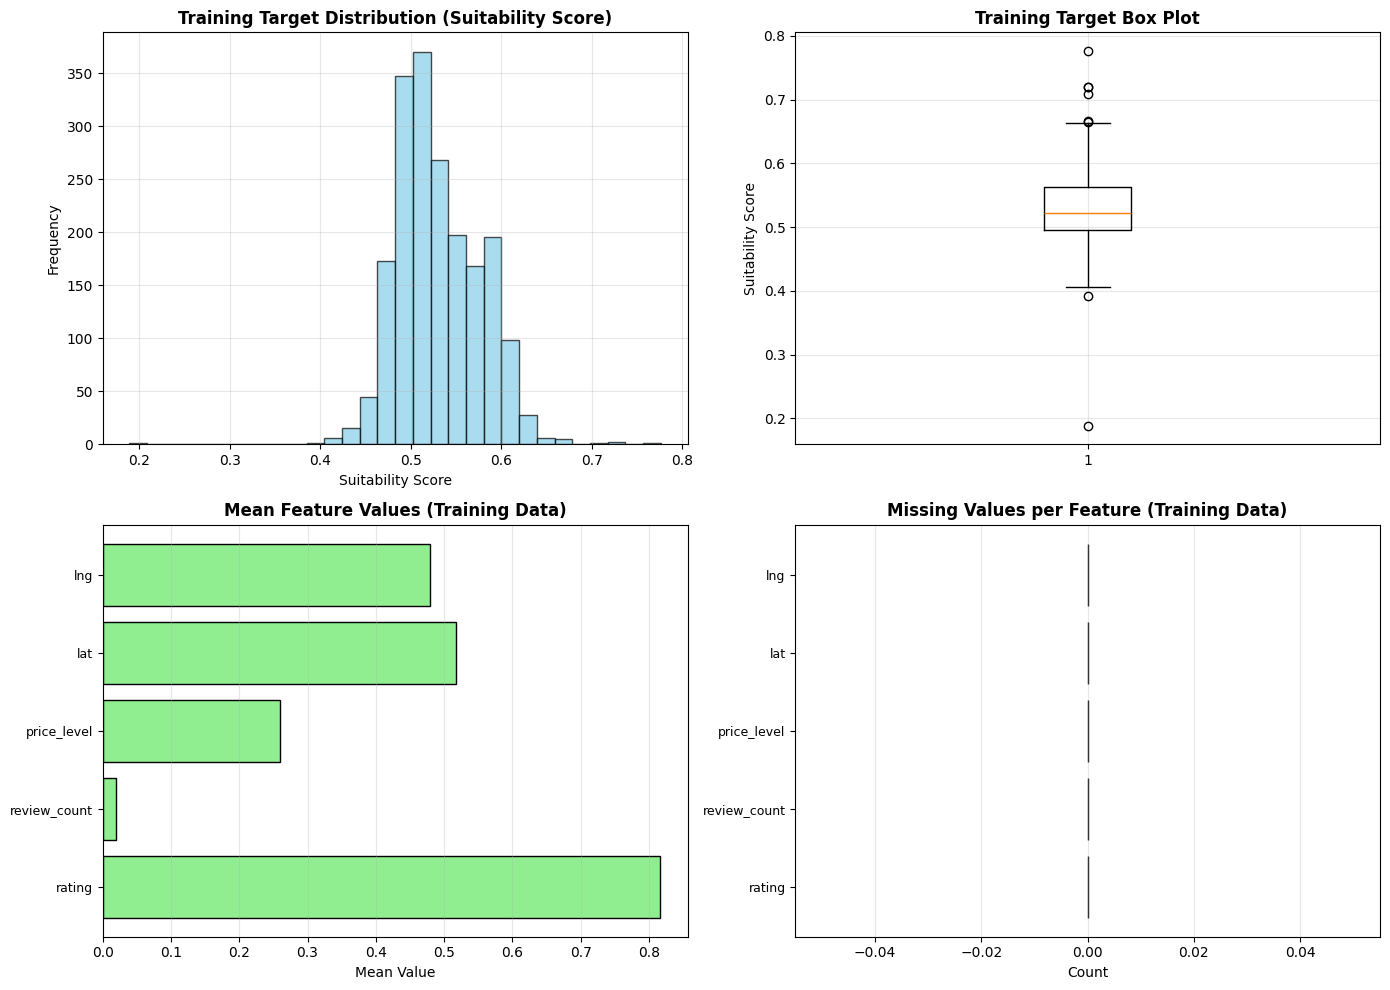

✓ Visualization saved to ../outputs/train_data_overview.png


In [39]:
# Data distribution
import matplotlib.pyplot as plt
import os

# Create outputs directory if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
axes[0, 0].hist(y_train, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Training Target Distribution (Suitability Score)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Suitability Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Box plot of target
axes[0, 1].boxplot(y_train, vert=True)
axes[0, 1].set_title('Training Target Box Plot', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Suitability Score')
axes[0, 1].grid(alpha=0.3)

# Feature means
feature_means = X_train.mean()
axes[1, 0].barh(range(len(feature_means)), feature_means.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_yticks(range(len(feature_means)))
axes[1, 0].set_yticklabels(feature_means.index, fontsize=9)
axes[1, 0].set_title('Mean Feature Values (Training Data)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mean Value')
axes[1, 0].grid(alpha=0.3, axis='x')

# Missing values
missing_counts = X_train.isnull().sum()
axes[1, 1].barh(range(len(missing_counts)), missing_counts.values, color='coral', edgecolor='black')
axes[1, 1].set_yticks(range(len(missing_counts)))
axes[1, 1].set_yticklabels(missing_counts.index, fontsize=9)
axes[1, 1].set_title('Missing Values per Feature (Training Data)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/train_data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to ../outputs/train_data_overview.png")

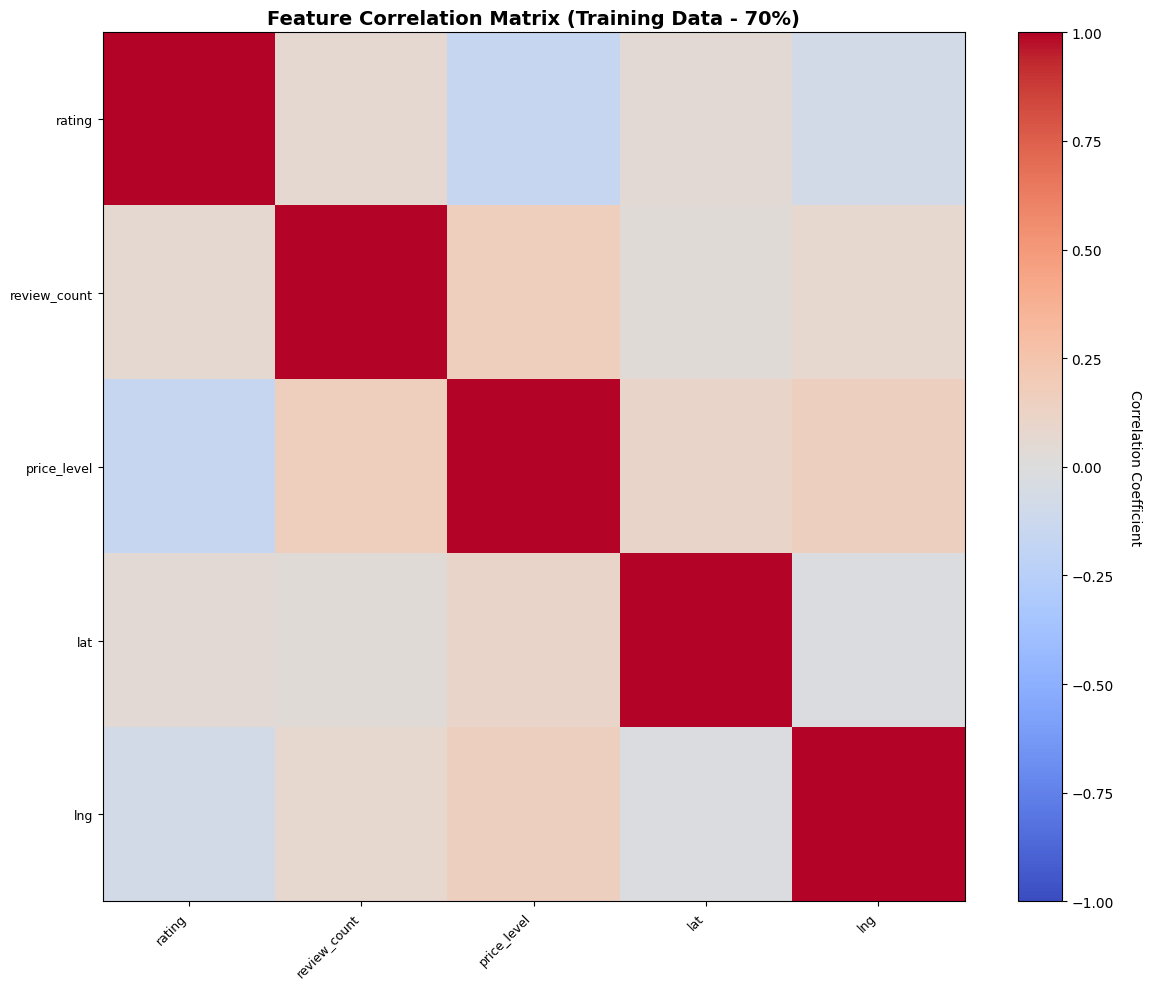

✓ Correlation matrix saved to ../outputs/train_correlation_matrix.png


In [40]:
# Correlation analysis for training data
correlation_matrix = X_train.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(correlation_matrix.columns, fontsize=9)
ax.set_title('Feature Correlation Matrix (Training Data - 70%)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)
plt.tight_layout()
plt.savefig('../outputs/train_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation matrix saved to ../outputs/train_correlation_matrix.png")

In [41]:
# Export training data
print("\n" + "="*80)
print("EXPORTING TRAINING DATA")
print("="*80)

# Save as CSV
X_train.to_csv('../data/train_features_70percent.csv', index=False)
y_train.to_csv('../data/train_target_70percent.csv', index=False)

# Save as pickle (maintains data types)
import pickle
with open('../data/train_X.pkl', 'wb') as f:
    pickle.dump(X_train, f)
with open('../data/train_y.pkl', 'wb') as f:
    pickle.dump(y_train, f)

print(f"✓ Saved train features to train_features_70percent.csv ({X_train.shape})")
print(f"✓ Saved train target to train_target_70percent.csv ({y_train.shape})")
print(f"✓ Saved train data to pickle files (train_X.pkl, train_y.pkl)")
print(f"\n🎯 TRAINING DATA (70%) IS READY FOR MODEL TRAINING")


EXPORTING TRAINING DATA
✓ Saved train features to train_features_70percent.csv ((1927, 5))
✓ Saved train target to train_target_70percent.csv ((1927,))
✓ Saved train data to pickle files (train_X.pkl, train_y.pkl)

🎯 TRAINING DATA (70%) IS READY FOR MODEL TRAINING
